# Bank Term Deposit Subscription Prediction

## 1. Import Libraries and Setup

In [9]:
# Install all required packages
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn tensorflow keras shap joblib --upgrade

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [6]:
# Uninstall and reinstall numpy
!conda install -c conda-forge numpy -y

Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\user\anaconda3

  added / updated specs:
    - numpy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       h4c7d964_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py312h2e8e312_0         1.1 MB  conda-forge
    openssl-3.6.1              |       hf411b9b_1         8.9 MB  conda-forge
    python_abi-3.12            |          3_cp312           6 KB
    ucrt-10.0.26100.0          |       h57928b3_0         678 KB  conda-forge
    vc-14.3                    |      h41ae7f8_34          19 KB  conda-forge
    vc14_runtime-14.44.35208   |      h818238b_34         667 KB  conda-forge
    vcomp14-14.44.35208        |      h818

'L' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

# Explainability
import shap

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Utilities
import joblib
from datetime import datetime
import json

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.12 from "c:\Users\user\anaconda3\python.exe"
  * The NumPy version is: "1.26.4"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: numpy._core.multiarray failed to import

## 2. Load and Explore Data

In [ ]:
train_df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\DS Projects\train (3).csv')
test_df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\DS Projects\test (2).csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print("\nTrain columns:", train_df.columns.tolist())

Train shape: (750000, 18)
Test shape: (250000, 17)

Train columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
train_df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [ ]:
print("Missing values in train:")
print(train_df.isnull().sum())
print("\nMissing values in test:")
print(test_df.isnull().sum())

Missing values in train:
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Missing values in test:
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


Target distribution:
y
0    659512
1     90488
Name: count, dtype: int64

Target proportion:
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


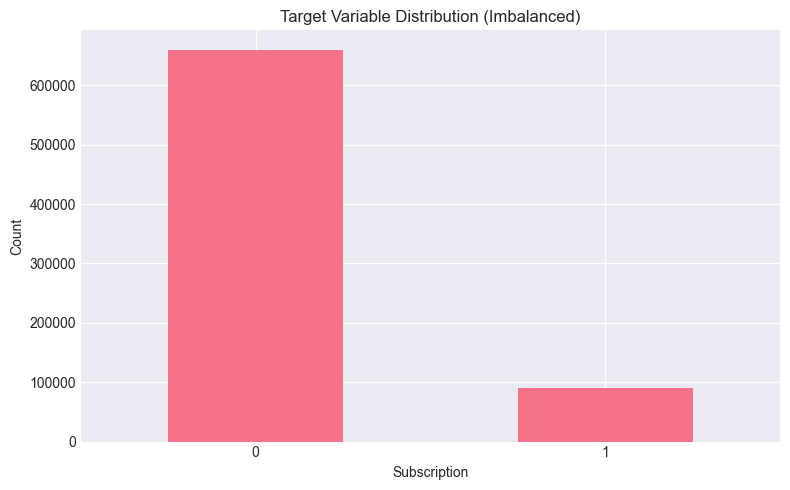

In [ ]:
print("Target distribution:")
print(train_df['y'].value_counts())
print("\nTarget proportion:")
print(train_df['y'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
train_df['y'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution (Imbalanced)')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

In [ ]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'y' in numeric_cols:
    numeric_cols.remove('y')
if 'id' in numeric_cols:
    numeric_cols.remove('id')

categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
train_df[numeric_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000


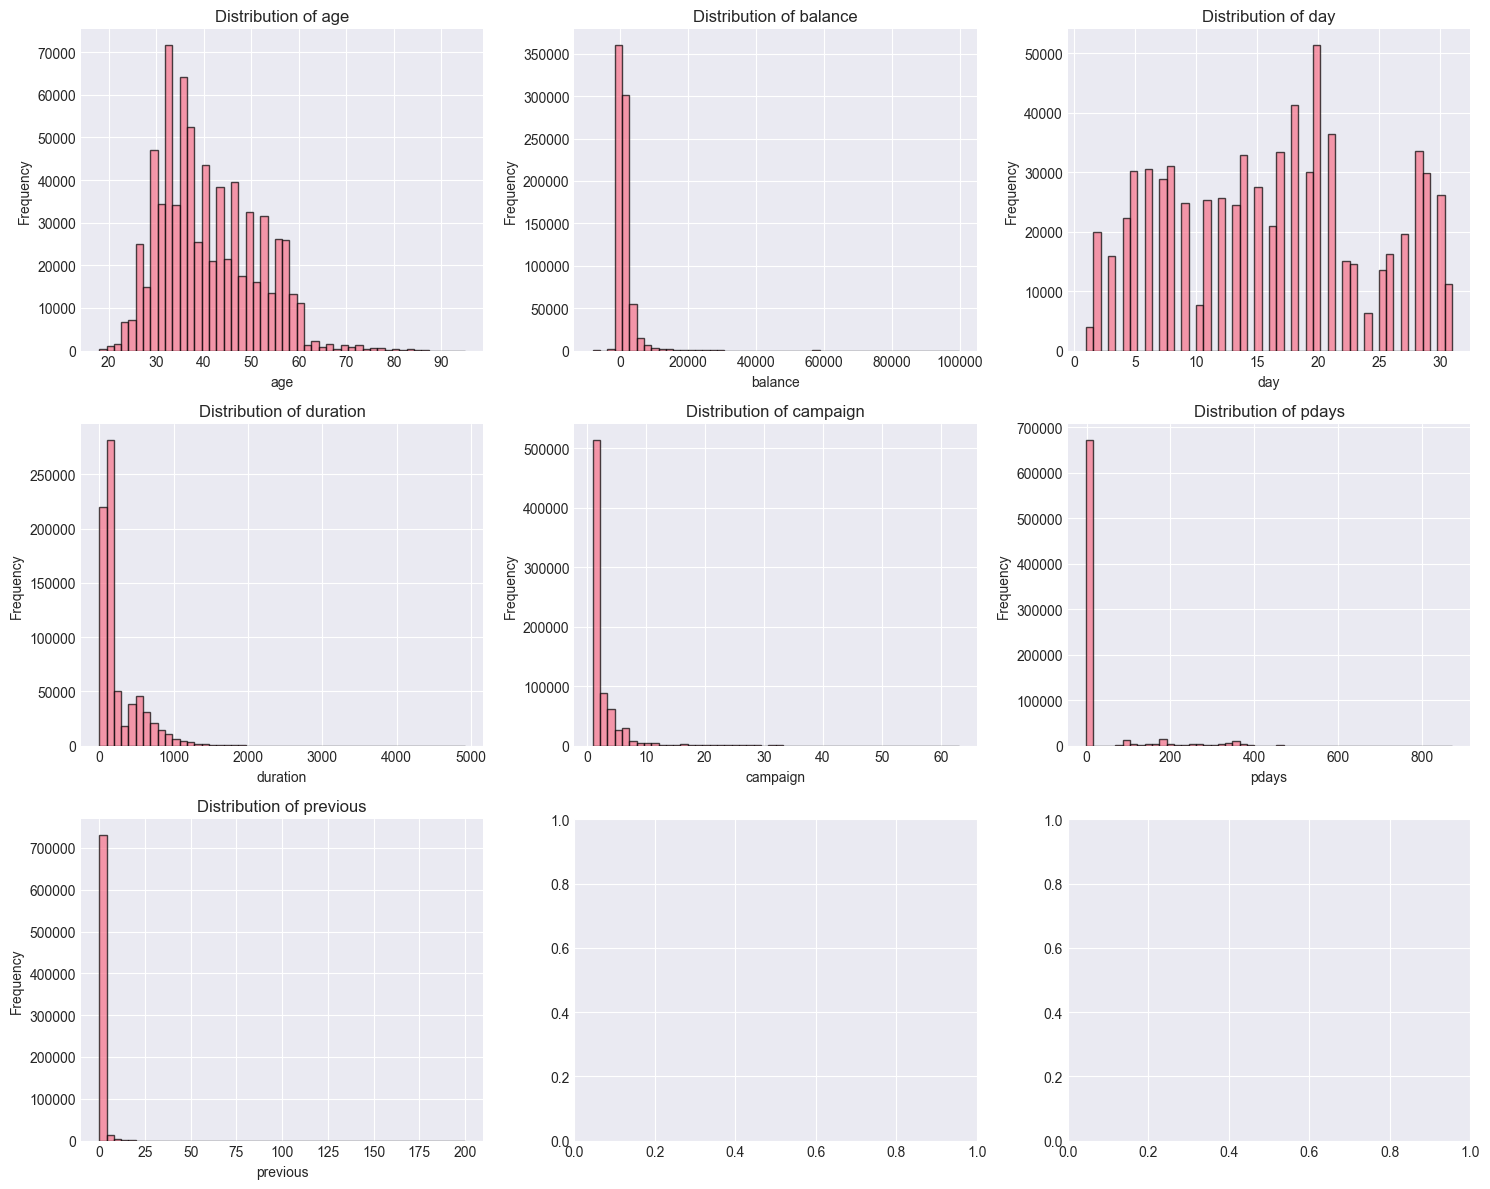

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:9]):
    axes[i].hist(train_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

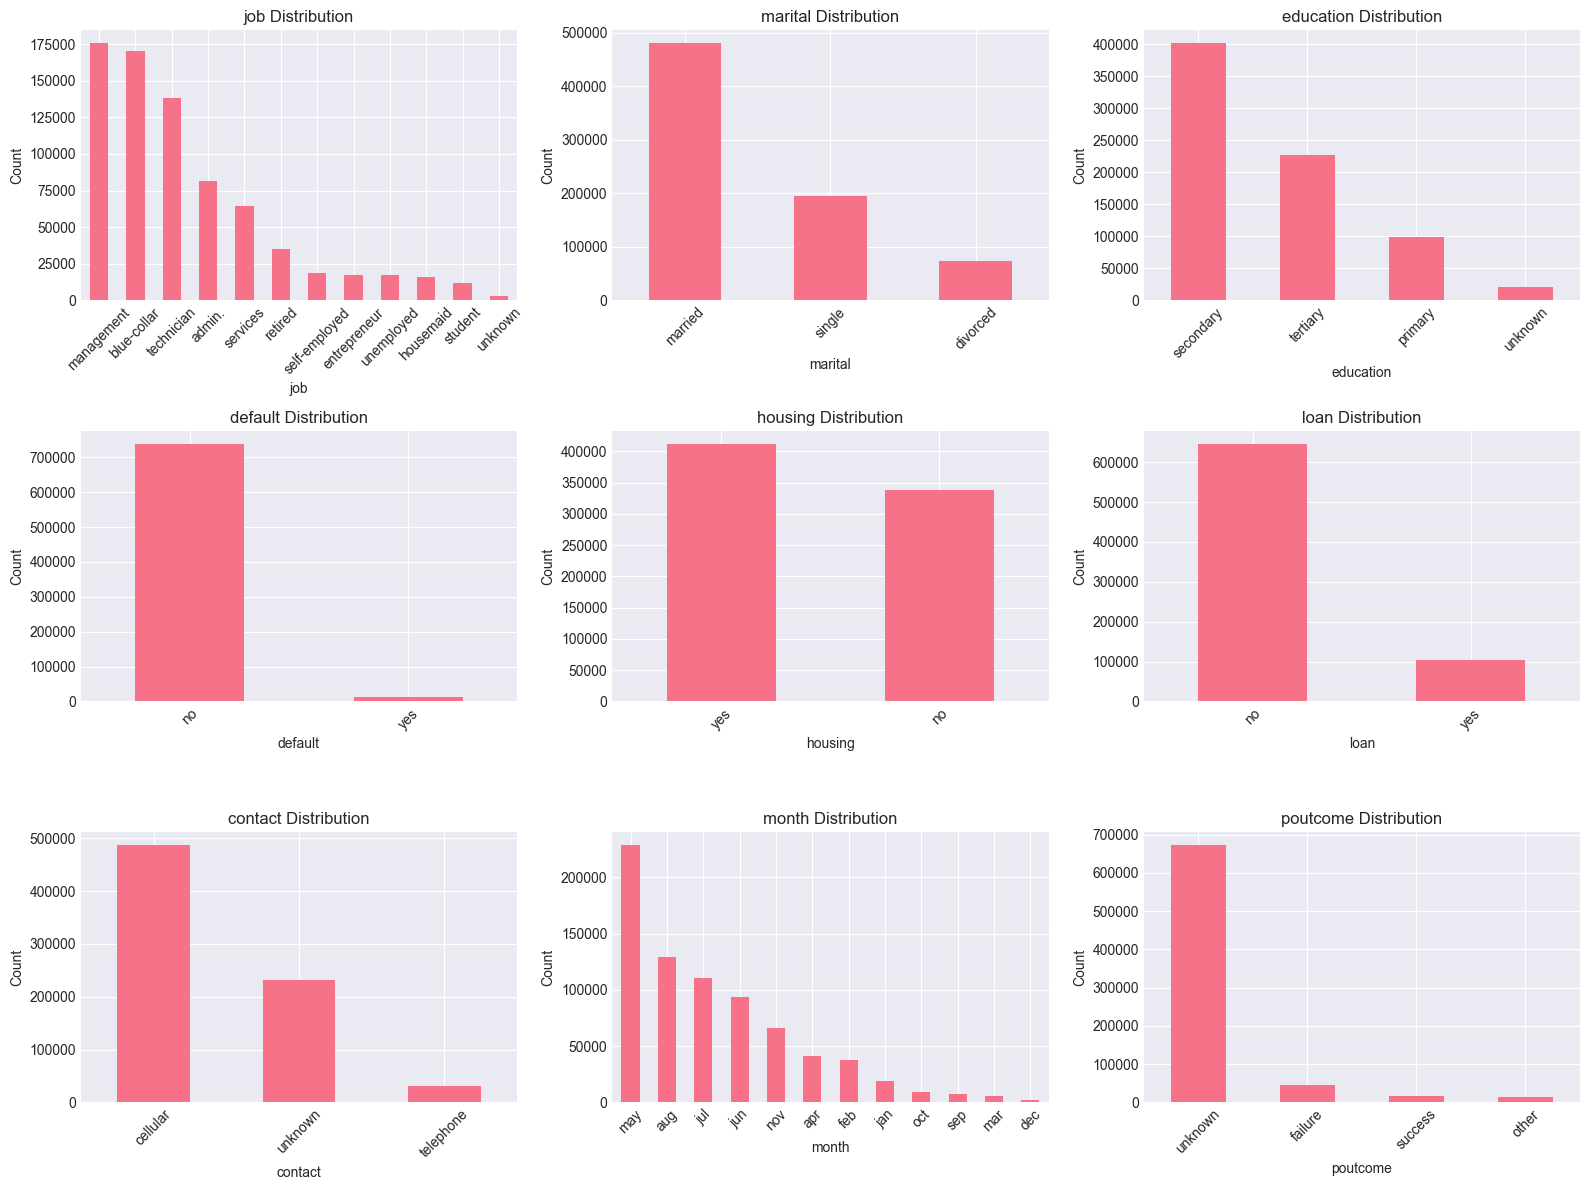

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols[:9]):
    train_df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

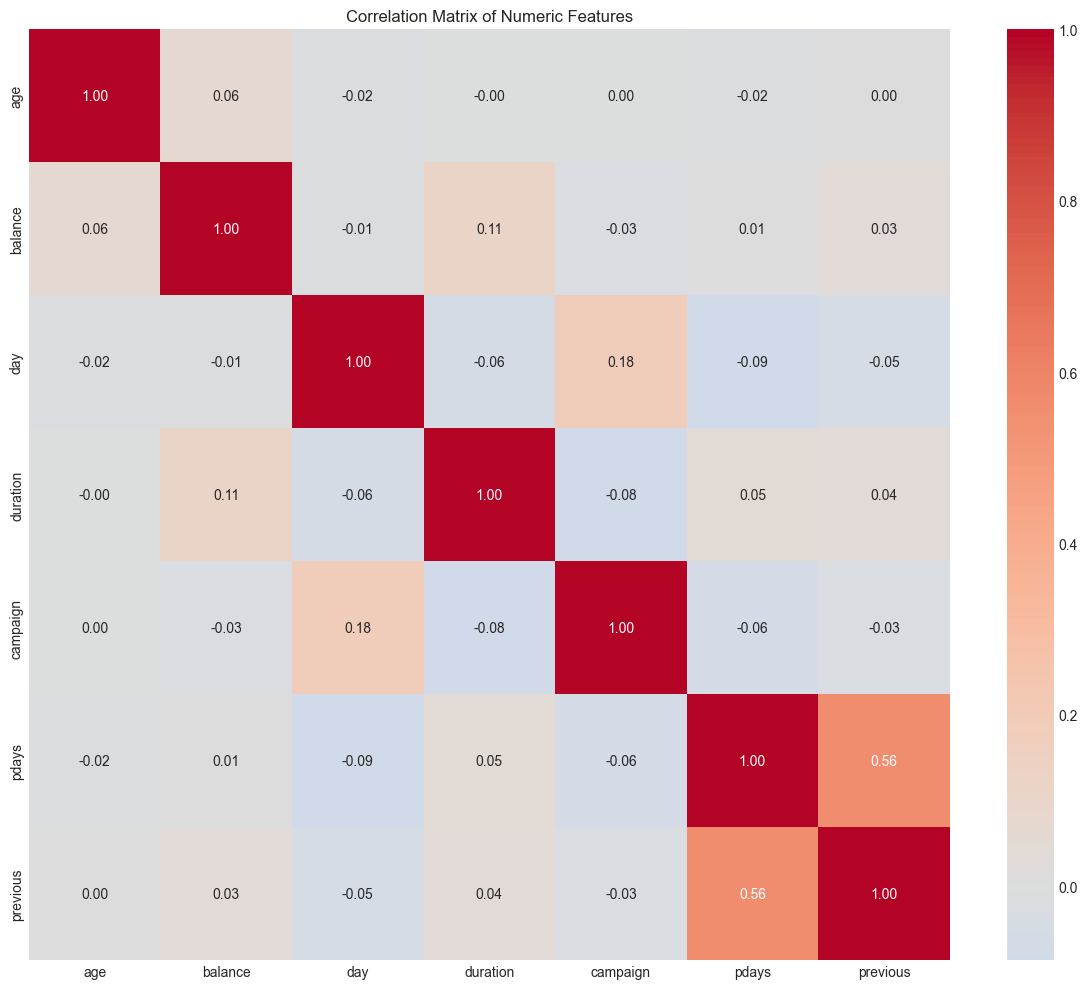

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = train_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

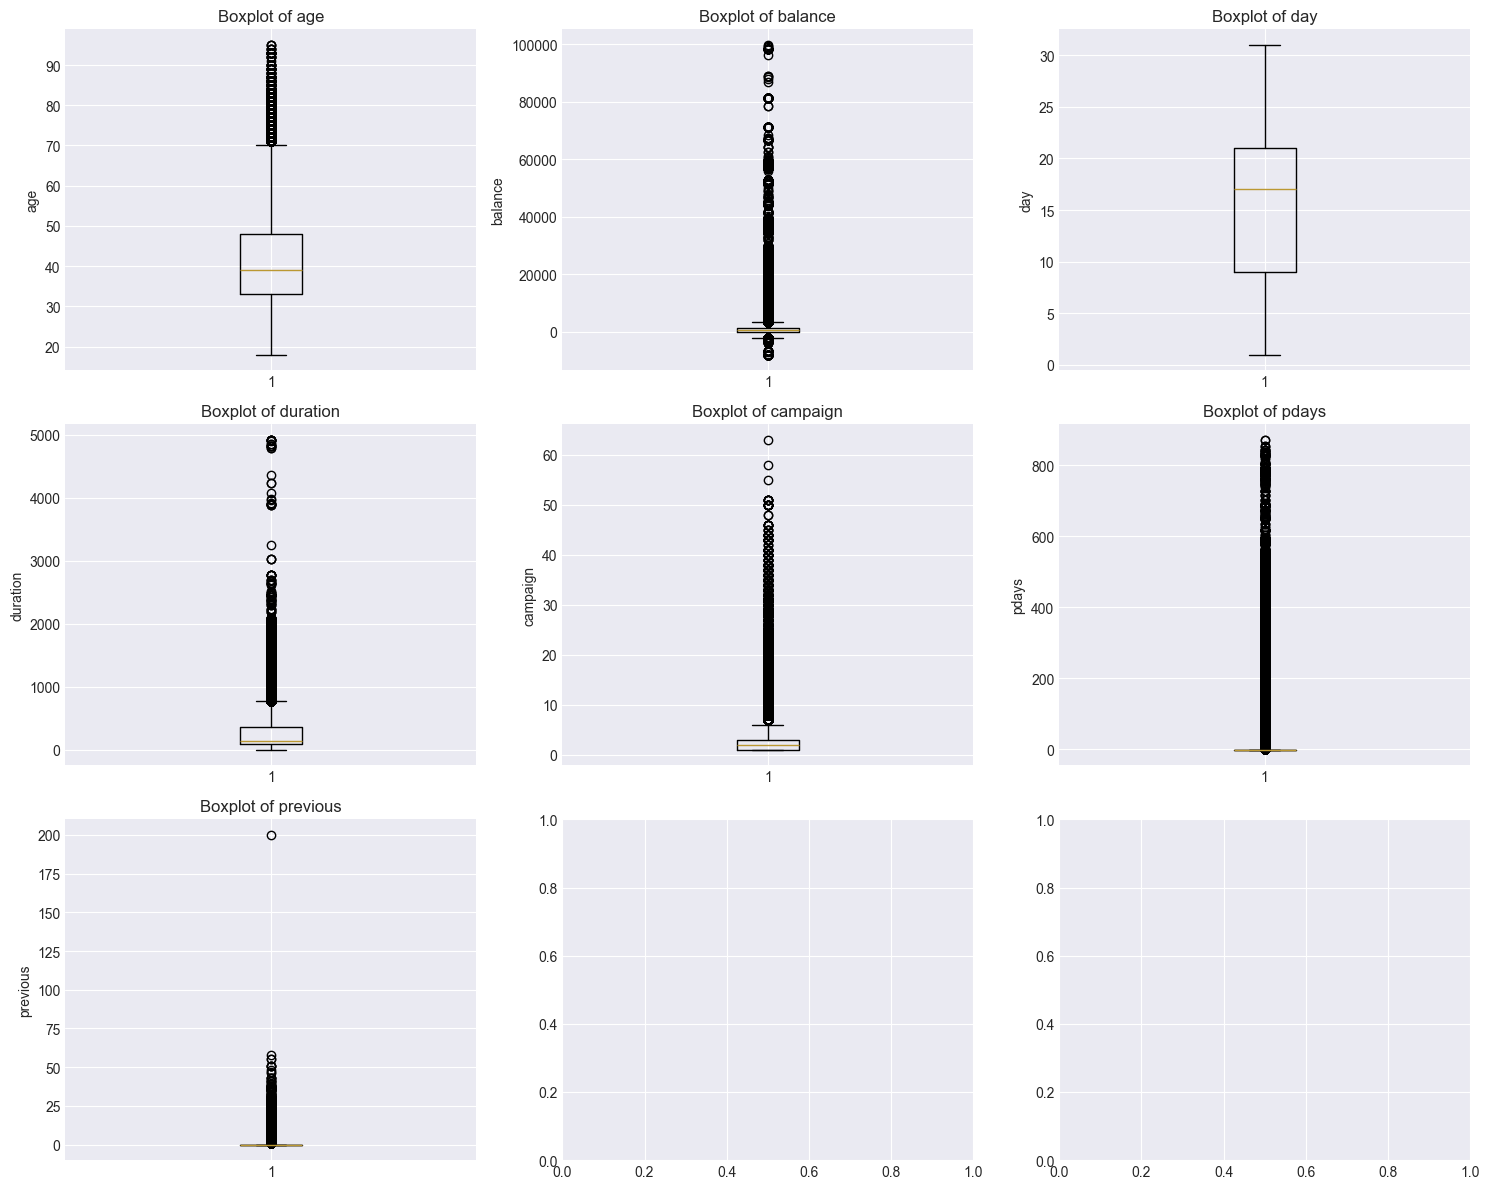

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:9]):
    axes[i].boxplot(train_df[col].dropna())
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom transformer for feature engineering
    Creates interaction features and derived variables
    """
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        if 'duration' in X.columns:
            X['duration_log'] = np.log1p(X['duration'])
            X['duration_squared'] = X['duration'] ** 2
        
        if 'balance' in X.columns:
            X['balance_positive'] = (X['balance'] > 0).astype(int)
            X['balance_log'] = np.log1p(X['balance'] - X['balance'].min() + 1)
        
        if 'age' in X.columns:
            X['age_group'] = pd.cut(X['age'], bins=[0, 30, 40, 50, 60, 100], 
                                    labels=['young', 'middle', 'senior', 'old', 'elderly'])
        
        if 'campaign' in X.columns:
            X['high_campaign'] = (X['campaign'] > 3).astype(int)
        
        if 'pdays' in X.columns:
            X['was_contacted_before'] = (X['pdays'] != -1).astype(int)
        
        if 'month' in X.columns:
            month_mapping = {
                'mar': 'spring', 'apr': 'spring', 'may': 'spring',
                'jun': 'summer', 'jul': 'summer', 'aug': 'summer',
                'sep': 'fall', 'oct': 'fall', 'nov': 'fall',
                'dec': 'winter', 'jan': 'winter', 'feb': 'winter'
            }
            X['season'] = X['month'].map(month_mapping)
        
        if 'job' in X.columns and 'education' in X.columns:
            X['job_education'] = X['job'].astype(str) + '_' + X['education'].astype(str)
        
        if 'age' in X.columns and 'balance' in X.columns:
            X['age_balance_ratio'] = X['age'] / (X['balance'].abs() + 1)
        
        return X

fe = FeatureEngineer()
train_engineered = fe.fit_transform(train_df)
print(f"Original features: {train_df.shape[1]}")
print(f"After engineering: {train_engineered.shape[1]}")
print(f"New features created: {train_engineered.shape[1] - train_df.shape[1]}")

Original features: 18
After engineering: 28
New features created: 10


## 5. Build Preprocessing Pipeline

In [ ]:
X = train_df.drop(['y', 'id'], axis=1, errors='ignore')

print("Unique values in y:", train_df['y'].unique())
print("Data type:", train_df['y'].dtype)
print("Value counts:\n", train_df['y'].value_counts(dropna=False))

y = train_df['y'].astype(int)

print(f"\nNaN count in y: {y.isna().sum()}")
print(f"Final shapes — X: {X.shape}, y: {y.shape}")
print("Target distribution:\n", y.value_counts())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nTarget distribution in train:\n{y_train.value_counts(normalize=True)}")
print(f"\nTarget distribution in val:\n{y_val.value_counts(normalize=True)}")

Unique values in y: [0 1]
Data type: int64
Value counts:
 y
0    659512
1     90488
Name: count, dtype: int64

NaN count in y: 0
Final shapes — X: (750000, 16), y: (750000,)
Target distribution:
 y
0    659512
1     90488
Name: count, dtype: int64

Training set: (600000, 16)
Validation set: (150000, 16)

Target distribution in train:
y
0    0.87935
1    0.12065
Name: proportion, dtype: float64

Target distribution in val:
y
0    0.879347
1    0.120653
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

X_train_fe = fe.fit_transform(X_train)
X_val_fe = fe.transform(X_val)

numeric_features = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

education_order = ['unknown', 'primary', 'secondary', 'tertiary']

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 14
Categorical features: 12


In [ ]:
from sklearn.preprocessing import RobustScaler

numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train_fe)
X_val_processed = preprocessor.transform(X_val_fe)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed validation shape: {X_val_processed.shape}")

Processed training shape: (600000, 115)
Processed validation shape: (150000, 115)


## 6. Model Training and Evaluation

In [ ]:
model_results = {}

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """
    Train model and evaluate performance
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print('='*60)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Probabilities (for ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_val_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_train_proba = model.decision_function(X_train)
        y_val_proba = model.decision_function(X_val)
    
    # Metrics
    results = {
        'model': model,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'train_precision': precision_score(y_train, y_train_pred),
        'val_precision': precision_score(y_val, y_val_pred),
        'train_recall': recall_score(y_train, y_train_pred),
        'val_recall': recall_score(y_val, y_val_pred),
        'train_f1': f1_score(y_train, y_train_pred),
        'val_f1': f1_score(y_val, y_val_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'val_roc_auc': roc_auc_score(y_val, y_val_proba),
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba
    }
    
    print(f"\nTraining Metrics:")
    print(f"  Accuracy: {results['train_accuracy']:.4f}")
    print(f"  Precision: {results['train_precision']:.4f}")
    print(f"  Recall: {results['train_recall']:.4f}")
    print(f"  F1-Score: {results['train_f1']:.4f}")
    print(f"  ROC-AUC: {results['train_roc_auc']:.4f}")
    
    print(f"\nValidation Metrics:")
    print(f"  Accuracy: {results['val_accuracy']:.4f}")
    print(f"  Precision: {results['val_precision']:.4f}")
    print(f"  Recall: {results['val_recall']:.4f}")
    print(f"  F1-Score: {results['val_f1']:.4f}")
    print(f"  ROC-AUC: {results['val_roc_auc']:.4f}")
    
    return results

### 6.1 Baseline Models

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_results['Logistic Regression'] = evaluate_model(
    lr_model, X_train_processed, y_train, X_val_processed, y_val, 'Logistic Regression'
)


Training: Logistic Regression

Training Metrics:
  Accuracy: 0.8599
  Precision: 0.4592
  Recall: 0.9058
  F1-Score: 0.6094
  ROC-AUC: 0.9460

Validation Metrics:
  Accuracy: 0.8611
  Precision: 0.4615
  Recall: 0.9085
  F1-Score: 0.6121
  ROC-AUC: 0.9465


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_results['Random Forest'] = evaluate_model(
    rf_model, X_train_processed, y_train, X_val_processed, y_val, 'Random Forest'
)


Training: Random Forest

Training Metrics:
  Accuracy: 0.9039
  Precision: 0.5592
  Recall: 0.9620
  F1-Score: 0.7073
  ROC-AUC: 0.9783

Validation Metrics:
  Accuracy: 0.8918
  Precision: 0.5302
  Recall: 0.9062
  F1-Score: 0.6690
  ROC-AUC: 0.9617


### 6.2 Advanced Models

In [ ]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle imbalance
    random_state=42,
    n_jobs=-1
)
model_results['XGBoost'] = evaluate_model(
    xgb_model, X_train_processed, y_train, X_val_processed, y_val, 'XGBoost'
)


Training: XGBoost

Training Metrics:
  Accuracy: 0.8816
  Precision: 0.5050
  Recall: 0.9449
  F1-Score: 0.6582
  ROC-AUC: 0.9675

Validation Metrics:
  Accuracy: 0.8809
  Precision: 0.5035
  Recall: 0.9397
  F1-Score: 0.6557
  ROC-AUC: 0.9647


In [ ]:
# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model_results['LightGBM'] = evaluate_model(
    lgbm_model, X_train_processed, y_train, X_val_processed, y_val, 'LightGBM'
)


Training: LightGBM

Training Metrics:
  Accuracy: 0.8796
  Precision: 0.5005
  Recall: 0.9427
  F1-Score: 0.6538
  ROC-AUC: 0.9660

Validation Metrics:
  Accuracy: 0.8797
  Precision: 0.5007
  Recall: 0.9409
  F1-Score: 0.6536
  ROC-AUC: 0.9644


In [ ]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
model_results['Gradient Boosting'] = evaluate_model(
    gb_model, X_train_processed, y_train, X_val_processed, y_val, 'Gradient Boosting'
)


Training: Gradient Boosting

Training Metrics:
  Accuracy: 0.9366
  Precision: 0.7768
  Recall: 0.6654
  F1-Score: 0.7168
  ROC-AUC: 0.9665

Validation Metrics:
  Accuracy: 0.9336
  Precision: 0.7638
  Recall: 0.6509
  F1-Score: 0.7029
  ROC-AUC: 0.9647


In [ ]:
# Naive Bayes
nb_model = GaussianNB()
model_results['Naive Bayes'] = evaluate_model(
    nb_model, X_train_processed, y_train, X_val_processed, y_val, 'Naive Bayes'
)


Training: Naive Bayes

Training Metrics:
  Accuracy: 0.8384
  Precision: 0.3913
  Recall: 0.6102
  F1-Score: 0.4768
  ROC-AUC: 0.8413

Validation Metrics:
  Accuracy: 0.8375
  Precision: 0.3884
  Recall: 0.6032
  F1-Score: 0.4725
  ROC-AUC: 0.8373


### 6.3 Deep Learning Model

In [ ]:
# Build Neural Network
def build_deep_learning_model(input_dim):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.AUC()]
    )
    
    return model

# Create model
dl_model = build_deep_learning_model(X_train_processed.shape[1])
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

 Trainable params: 73,857 (288.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train Deep Learning Model
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

history = dl_model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.8340 - auc: 0.9360 - loss: 0.3114 - precision: 0.4155 - recall: 0.9243 - val_accuracy: 0.8486 - val_auc: 0.9542 - val_loss: 0.2759 - val_precision: 0.4408 - val_recall: 0.9493 - learning_rate: 0.0010
Epoch 2/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.8531 - auc: 0.9485 - loss: 0.2771 - precision: 0.4478 - recall: 0.9335 - val_accuracy: 0.8581 - val_auc: 0.9564 - val_loss: 0.2771 - val_precision: 0.4573 - val_recall: 0.9436 - learning_rate: 0.0010
Epoch 3/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.8586 - auc: 0.9511 - loss: 0.2700 - precision: 0.4578 - recall: 0.9338 - val_accuracy: 0.8661 - val_auc: 0.9573 - val_loss: 0.2791 - val_precision: 0.4724 - val_recall: 0.9389 - learning_rate: 0.0010
Epoch 4/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.8595 - auc: 0.9528 - loss: 0.2651 - precision: 0.4595 - recall: 0.9356 - val_accuracy: 0.8653 - val_auc: 0.9582 - val_lo

In [ ]:
# Evaluate Deep Learning Model
y_train_pred_dl = (dl_model.predict(X_train_processed) > 0.5).astype(int).ravel()
y_val_pred_dl = (dl_model.predict(X_val_processed) > 0.5).astype(int).ravel()
y_train_proba_dl = dl_model.predict(X_train_processed).ravel()
y_val_proba_dl = dl_model.predict(X_val_processed).ravel()

model_results['Deep Learning'] = {
    'model': dl_model,
    'train_accuracy': accuracy_score(y_train, y_train_pred_dl),
    'val_accuracy': accuracy_score(y_val, y_val_pred_dl),
    'train_precision': precision_score(y_train, y_train_pred_dl),
    'val_precision': precision_score(y_val, y_val_pred_dl),
    'train_recall': recall_score(y_train, y_train_pred_dl),
    'val_recall': recall_score(y_val, y_val_pred_dl),
    'train_f1': f1_score(y_train, y_train_pred_dl),
    'val_f1': f1_score(y_val, y_val_pred_dl),
    'train_roc_auc': roc_auc_score(y_train, y_train_proba_dl),
    'val_roc_auc': roc_auc_score(y_val, y_val_proba_dl),
    'y_val_pred': y_val_pred_dl,
    'y_val_proba': y_val_proba_dl
}

print("Deep Learning Model Results:")
print(f"Validation Accuracy: {model_results['Deep Learning']['val_accuracy']:.4f}")
print(f"Validation Precision: {model_results['Deep Learning']['val_precision']:.4f}")
print(f"Validation Recall: {model_results['Deep Learning']['val_recall']:.4f}")
print(f"Validation F1-Score: {model_results['Deep Learning']['val_f1']:.4f}")
print(f"Validation ROC-AUC: {model_results['Deep Learning']['val_roc_auc']:.4f}")

18750/18750 ━━━━━━━━━━━━━━━━━━━━ 68s 4ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
Deep Learning Model Results:
Validation Accuracy: 0.8775
Validation Precision: 0.4960
Validation Recall: 0.9359
Validation F1-Score: 0.6484
Validation ROC-AUC: 0.9627


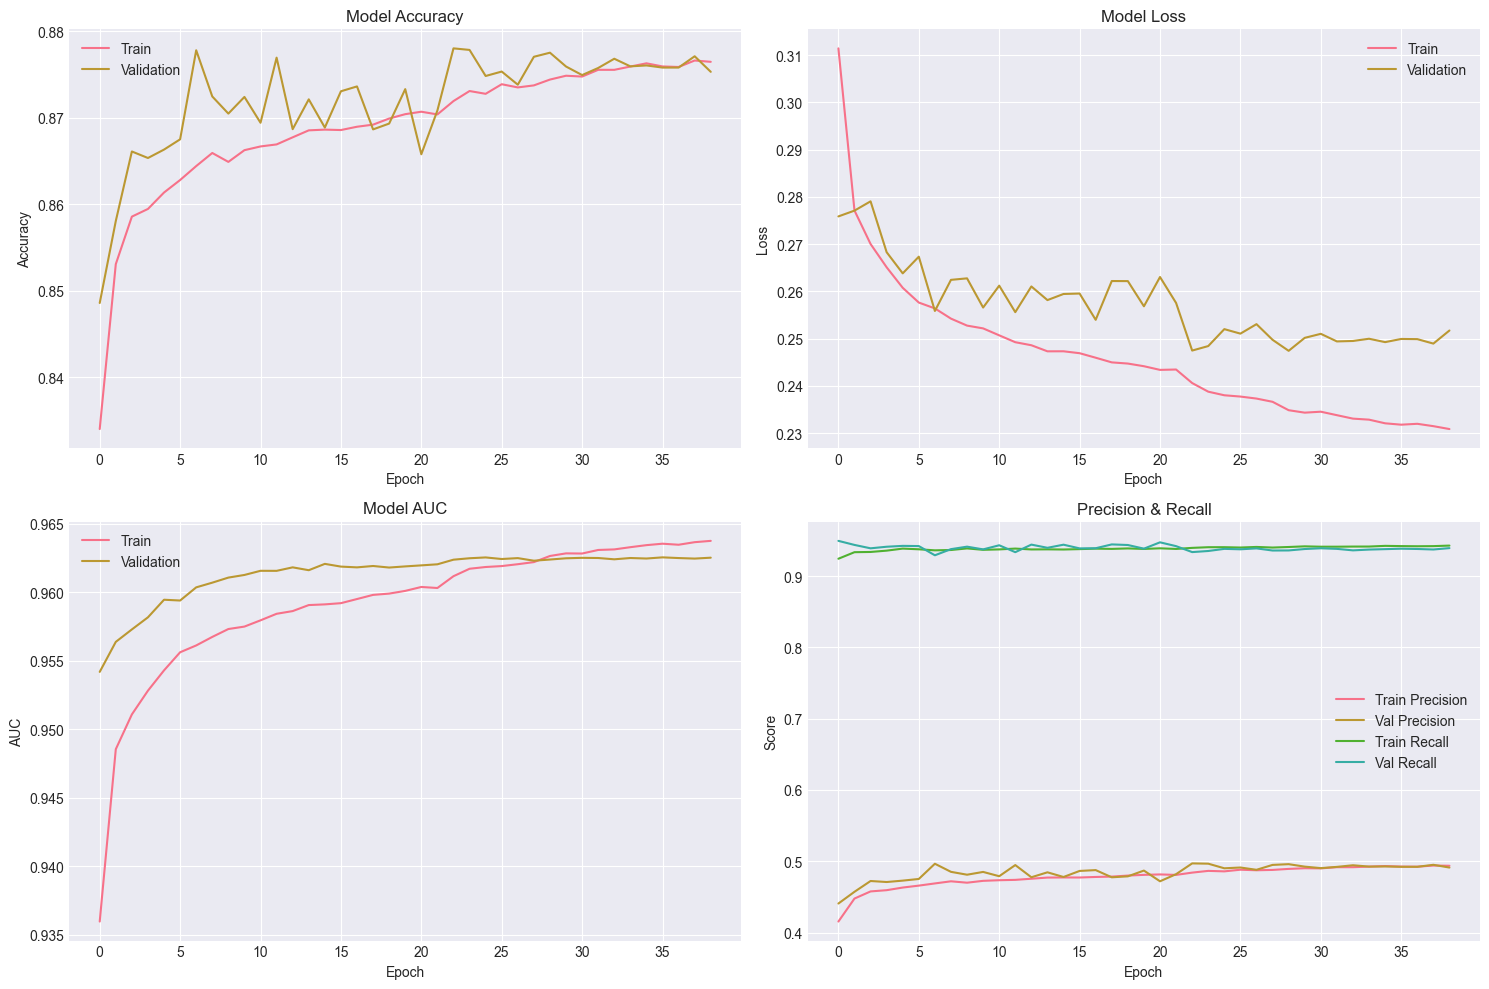

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train')
axes[1, 0].plot(history.history['val_auc'], label='Validation')
axes[1, 0].set_title('Model AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 (Precision + Recall)
axes[1, 1].plot(history.history['precision'], label='Train Precision')
axes[1, 1].plot(history.history['val_precision'], label='Val Precision')
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Precision & Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 6.4 Ensemble Model

In [ ]:
# Create Voting Ensemble with best models
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('rf', rf_model)
    ],
    voting='soft',
    n_jobs=-1
)

model_results['Ensemble'] = evaluate_model(
    ensemble_model, X_train_processed, y_train, X_val_processed, y_val, 'Ensemble (Voting)'
)


Training: Ensemble (Voting)

Training Metrics:
  Accuracy: 0.8882
  Precision: 0.5200
  Recall: 0.9494
  F1-Score: 0.6720
  ROC-AUC: 0.9720

Validation Metrics:
  Accuracy: 0.8848
  Precision: 0.5124
  Recall: 0.9342
  F1-Score: 0.6618
  ROC-AUC: 0.9645


## 7. Model Comparison and Leaderboard

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Train Accuracy': [model_results[m]['train_accuracy'] for m in model_results],
    'Val Accuracy': [model_results[m]['val_accuracy'] for m in model_results],
    'Val Precision': [model_results[m]['val_precision'] for m in model_results],
    'Val Recall': [model_results[m]['val_recall'] for m in model_results],
    'Val F1': [model_results[m]['val_f1'] for m in model_results],
    'Val ROC-AUC': [model_results[m]['val_roc_auc'] for m in model_results]
})

# Sort by validation F1 score
comparison_df = comparison_df.sort_values('Val ROC-AUC', ascending=False).reset_index(drop=True)
comparison_df.index += 1  

print("\n" + "="*80)
print("MODEL LEADERBOARD - Ranked by Validation ROC-AUC")
print("="*80)
print(comparison_df.to_string())


MODEL LEADERBOARD - Ranked by Validation ROC-AUC
                 Model  Train Accuracy  Val Accuracy  Val Precision  Val Recall    Val F1  Val ROC-AUC
1    Gradient Boosting        0.936572      0.933600       0.763844    0.650901  0.702864     0.964724
2              XGBoost        0.881587      0.880933       0.503523    0.939717  0.655704     0.964685
3             Ensemble        0.888165      0.884807       0.512410    0.934247  0.661826     0.964500
4             LightGBM        0.879567      0.879667       0.500706    0.940877  0.653591     0.964360
5        Deep Learning        0.879163      0.877520       0.495988    0.935905  0.648369     0.962708
6        Random Forest        0.903917      0.891787       0.530161    0.906177  0.668951     0.961655
7  Logistic Regression        0.859905      0.861060       0.461504    0.908498  0.612080     0.946522
8          Naive Bayes        0.838445      0.837500       0.388353    0.603216  0.472505     0.837297

Leaderboard saved to o

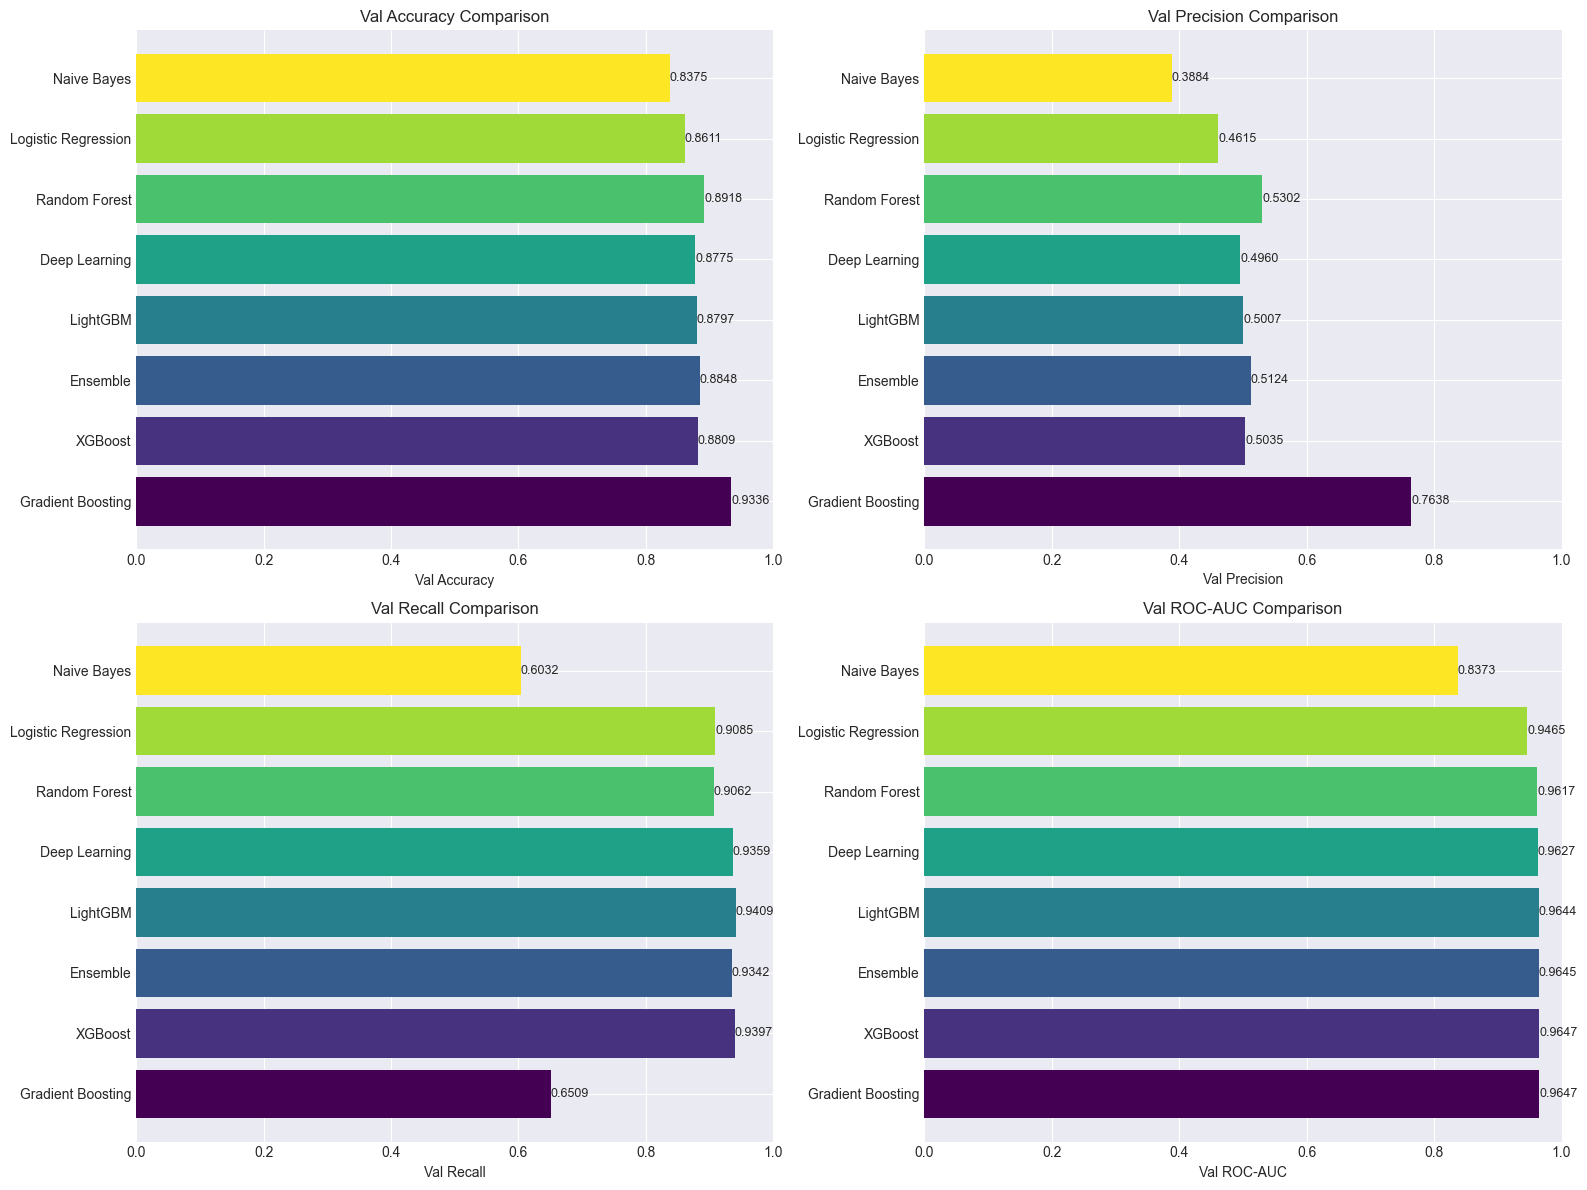

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Val Accuracy', 'Val Precision', 'Val Recall', 'Val ROC-AUC']
colors = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Confusion Matrices and ROC Curves

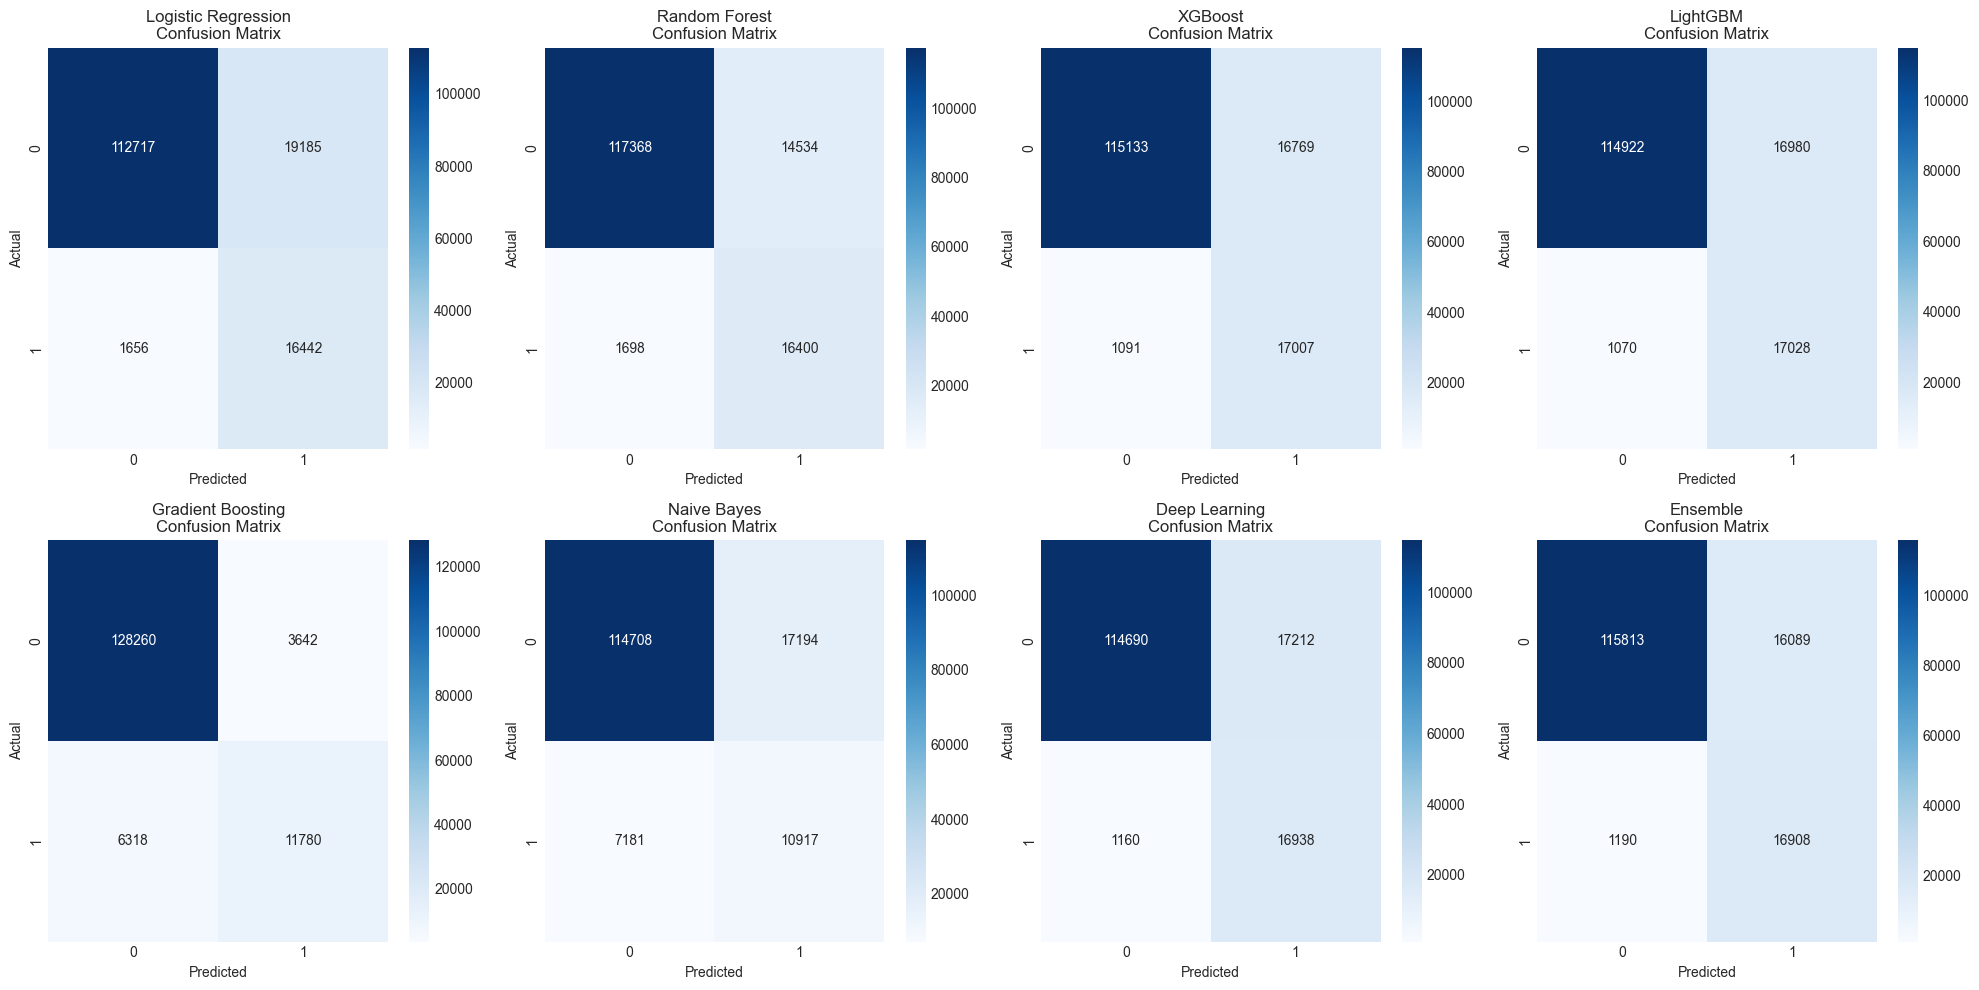

In [ ]:
# Plot confusion matrices for all models
n_models = len(model_results)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(model_results.items()):
    cm = confusion_matrix(y_val, results['y_val_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide extra subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

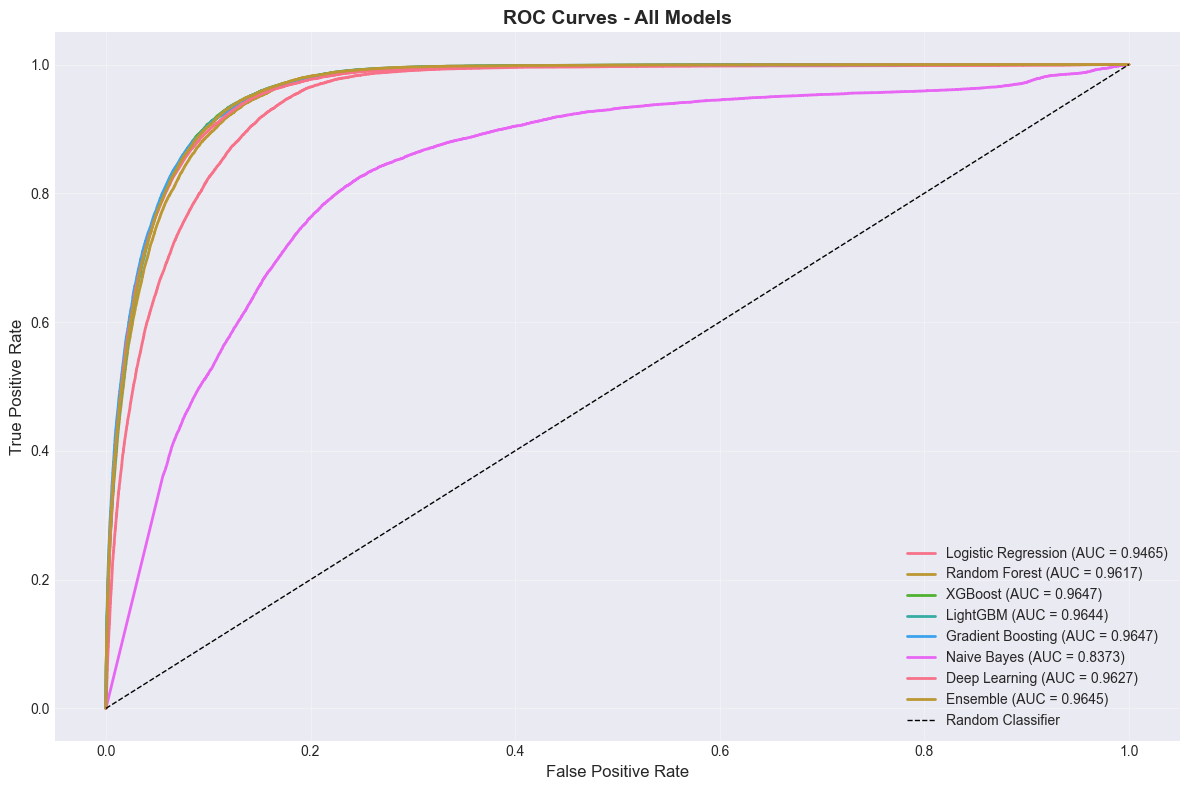

In [ ]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name, results in model_results.items():
    fpr, tpr, _ = roc_curve(y_val, results['y_val_proba'])
    auc_score = results['val_roc_auc']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Importance and SHAP Analysis

In [ ]:
# Get feature names 
feature_names = []

# Numeric features
feature_names.extend(numeric_features)

# Categorical features (one-hot encoded)
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
for i, cat_col in enumerate(categorical_features):
    categories = cat_encoder.categories_[i]
    feature_names.extend([f"{cat_col}_{cat}" for cat in categories])

print(f"Total features after preprocessing: {len(feature_names)}")

Total features after preprocessing: 115


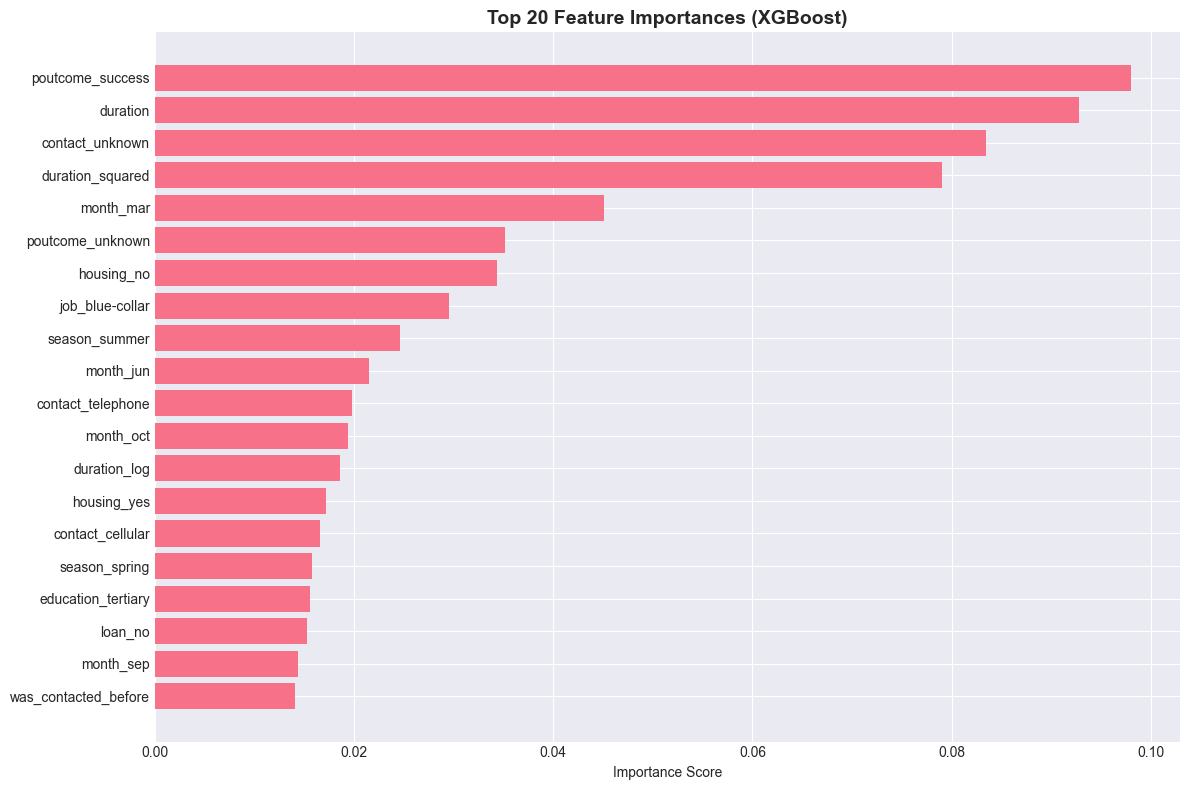


Top 20 Most Important Features:
1. poutcome_success: 0.0980
2. duration: 0.0928
3. contact_unknown: 0.0835
4. duration_squared: 0.0791
5. month_mar: 0.0451
6. poutcome_unknown: 0.0351
7. housing_no: 0.0344
8. job_blue-collar: 0.0295
9. season_summer: 0.0246
10. month_jun: 0.0215
11. contact_telephone: 0.0198
12. month_oct: 0.0194
13. duration_log: 0.0186
14. housing_yes: 0.0172
15. contact_cellular: 0.0166
16. season_spring: 0.0158
17. education_tertiary: 0.0155
18. loan_no: 0.0153
19. month_sep: 0.0143
20. was_contacted_before: 0.0140


In [ ]:
# Feature importance - Using XGBoost as it performed well
best_model = model_results['XGBoost']['model']

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 20 features
top_n = 20
plt.figure(figsize=(12, 8))
plt.title(f'Top {top_n} Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.barh(range(top_n), importances[indices[:top_n]][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 20 Most Important Features:")
for i in range(top_n):
    idx = indices[i]
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

In [ ]:
# SHAP Analysis
print("Computing SHAP values... This may take a few minutes.")

sample_size = min(5000, len(X_val_processed))
X_val_sample = X_val_processed[:sample_size]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_sample)

print("SHAP values computed successfully!")

Computing SHAP values... This may take a few minutes.
SHAP values computed successfully!


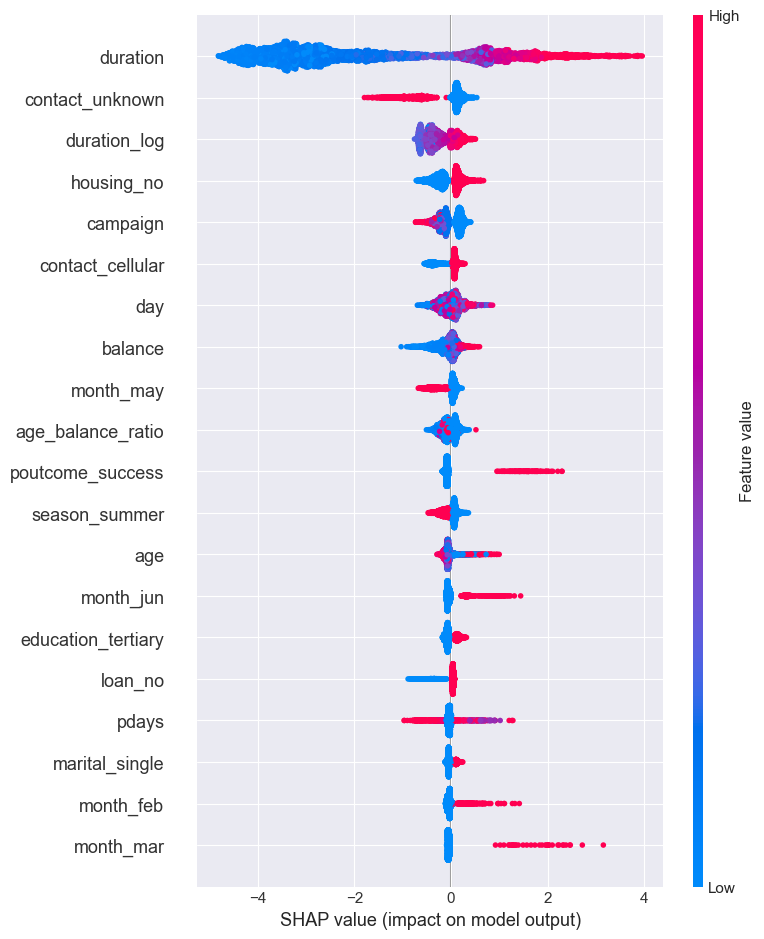

In [ ]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

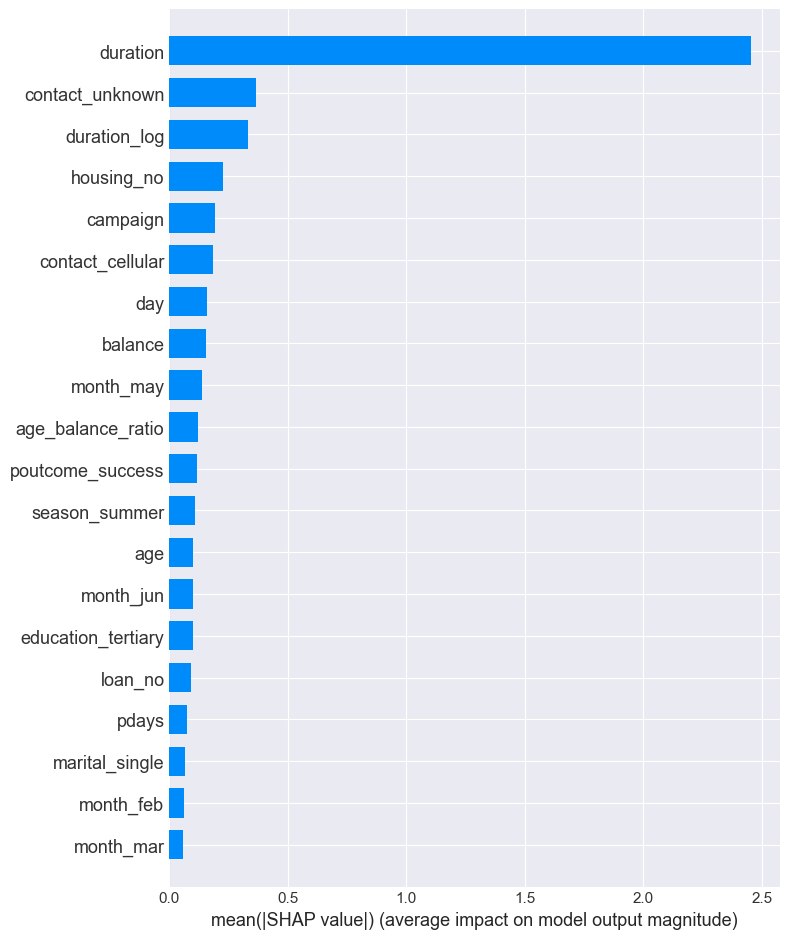

In [ ]:
# SHAP Bar Plot 
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## 10. Save Best Model and Pipeline

In [ ]:
# Identify best model based on ROC-AUC
best_model_name = comparison_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")
print(f"Validation ROC-AUC: {comparison_df.iloc[0]['Val ROC-AUC']:.4f}")

Best performing model: Gradient Boosting
Validation ROC-AUC: 0.9647

Best model pipeline saved to outputs/best_model_pipeline.pkl
Feature names saved to outputs/feature_names.json
Model metadata saved to outputs/model_metadata.json


## 11. Generate Predictions for Test Set

In [ ]:
# Prepare test data
X_test = test_df.drop(['id'], axis=1, errors='ignore')
test_ids = test_df['id'] if 'id' in test_df.columns else range(len(test_df))

# Make predictions using the complete pipeline
test_predictions_proba = complete_pipeline.predict_proba(X_test)[:, 1]
test_predictions = (test_predictions_proba > 0.5).astype(int)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'id': test_ids,
    'prediction': test_predictions,
    'probability': test_predictions_proba
})

print(f"\nPrediction distribution:")
print(submission_df['prediction'].value_counts())
print(f"\nPrediction rate: {submission_df['prediction'].mean():.2%}")

Test predictions saved to outputs/test_predictions.csv

Prediction distribution:
prediction
0    224174
1     25826
Name: count, dtype: int64

Prediction rate: 10.33%
